# [EXPERIMENTO] FAR con la misma proporción de varianza que el PSBPM-FD — 107, 108, 109

**Pregunta.** El `_05` de 107-109 ajusta **un** FAR(p) para todo el barrido, con `kn` elegido por
`seleccionar_kn` (hold-out en train, criterio L2, tope 12). El PSBPM-FD del punto `M` sólo ve las `M`
primeras autofunciones. Si `kn != M`, los dos modelos trabajan con subespacios distintos de la curva.

**Qué se hace aquí.** Para cada escenario y cada `M` se ajusta además `FAR(p = N_LAGS, kn = M)`.
Con `kn = M` el subespacio del FAR **es** el de la FPCA de `M` componentes; se verifica con `assert`
(cosenos principales = 1 y los mismos autovalores). Por lo tanto las dos predicciones viven en
`mu + span(psi_1..psi_M)`, con la misma varianza explicada y el mismo piso de truncamiento.

Evaluación: las diez métricas de `§02_02_03` con `ventana_movil_funcional(bloque_A=True)` para
`w ∈ {20, 30, 40}`, tablas en `W_REF = 30`, sin las ventanas que cruzan `T0` y contra `curva_suavizada`.
El Bloque B también se reporta contra `representacion_fpca`. La banda del FAR es la del `_05`
(σ(τ) de los residuos de train, inflada por `sqrt(1 + kn/n_train)`).

**Sólo lectura** de `escenario_107_*` y `escenario_108_*`. La 109 no tenía artefactos: sus datos salen de
`exp109_01_simulaciones.ipynb`, que es una copia del `109_01` con `BASENAME = "experimento_109"`.
Salidas: `reports/simulaciones/experimento_farkn_<esc>_r01/` (y01 varianza, y03 resumen de test, y04 ventanas ganadas, y05 figura).

## §1 Imports y `[CONFIG]`

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from model_psbp_fd.utils import get_project_root
from model_psbp_fd.utils.rutas import experiment_id, construir_paths
from model_psbp_fd.pipelines import (
    cargar_escenario, cargar_representacion, cargar_fpca, cargar_estandarizador,
    cargar_datasets_ar, cargar_hiperparametros, cargar_config_evaluacion,
)
from model_psbp_fd.functions_models import DataStandardizer
from model_psbp_fd.models.pspb_fd_v3 import PropagadorFuncional, ruta_traza, leer_traza, ModeloTraza
from model_psbp_fd.fit.rolling import ventana_movil_funcional

PROJECT_ROOT = get_project_root()
sys.path.insert(0, str(PROJECT_ROOT / "notebooks" / "simulaciones" / "experimento"))
import far_kn as fk

plt.style.use("seaborn-v0_8-darkgrid")
%matplotlib inline

In [2]:
# [CONFIG] escenario -> (BASENAME, ESCENARIO_ID, M con artefactos, S_POR_ITER del _04 de ese escenario)
ESCENARIOS = {
    "107": ("escenario_107",   1, (1, 2, 3, 4),       1),
    "108": ("escenario_108",   2, (1, 2, 3, 4, 5, 6), 3),
    "109": ("experimento_109", 3, (3, 4, 5, 6),       1),
}
REPLICA_ID  = 1
M_EVAL      = (1, 2, 3, 4, 5, 6)   # FAR(kn=M) se evalúa en todos: sólo necesita THETA
KN_MAX, CRITERIO_KN = 12, "L2"     # los del _05
IC_POR_TAU, IC_CORRECCION = True, True
S_FUNC, BLOQUE_ORIG, SEED_PRED = 1000, 200, 20260823   # los del _04
METRICAS_A = ["mae_f", "rmse_f", "linf_medio", "linf_max"]
METRICAS_B = ["mpiw", "picp", "picp_simultaneo", "winkler", "winkler_max_medio", "winkler_max_glob"]

## §2 Carga (sólo lectura), varianza explicada y el `kn` del `_05`

In [3]:
E = {}
for esc, (base, eid_esc, M_art, s_iter) in ESCENARIOS.items():
    P = {M: construir_paths(experiment_id(base, eid_esc, REPLICA_ID, M), crear=False) for M in M_art}
    Pref = P[M_art[-1]]
    ev = cargar_config_evaluacion(Pref)
    assert ev["objetivo_evaluacion"] == "curva_suavizada" and ev["modo_residuo"] == "ninguno"
    fr, THETA, _ = cargar_representacion(Pref)
    grilla = np.asarray(cargar_escenario(str(Pref["raw"] / f"escenario_{eid_esc}.npz"))["grilla"], float)   # los .npy no se versionan
    T0, NL, NIVEL = int(ev["T0"]), int(ev["n_lags"]), float(ev["nivel_credibilidad"])
    X_suav = fr.reconstruct(THETA)
    THETA_W, L = fk.coords_blanqueadas(fr, THETA)
    for M in M_art:   # los puntos comparten base y realización
        _, TH_M, _ = cargar_representacion(P[M])
        assert np.allclose(TH_M, THETA), f"[{esc} M={M}] THETA distinto"
    kn_cv, cv = fk.kn_por_cv(THETA_W, T0, NL, KN_MAX, CRITERIO_KN)
    vac = fk.var_acumulada(THETA_W, T0)
    n_orig = THETA.shape[0] - NL
    es_train = (np.arange(NL + 1, THETA.shape[0] + 1)) <= T0
    E[esc] = dict(base=base, P=P, M_art=M_art, s_iter=s_iter, ev=ev, fr=fr, THETA=THETA, grilla=grilla,
                  T0=T0, NL=NL, NIVEL=NIVEL, X_obj=X_suav[NL:], THETA_W=THETA_W, L=L,
                  kn_cv=kn_cv, cv=cv, vac=vac, n_orig=n_orig, es_train=es_train, T0_orig=T0 - NL,
                  ventanas=list(ev["ventana_movil"]["w"]), paso=int(ev["ventana_movil"]["paso"]),
                  solapadas=bool(ev["ventana_movil"]["solapadas"]),
                  out=PROJECT_ROOT / "reports" / "simulaciones" / f"experimento_farkn_{esc}_{eid_esc}_r{REPLICA_ID:02d}")
    E[esc]["out"].mkdir(parents=True, exist_ok=True)
    print(f"{esc}: K={THETA.shape[1]} T0={T0} N_LAGS={NL} · kn del _05 ({CRITERIO_KN}) = {kn_cv} "
          f"-> var {vac[kn_cv-1]:.2%}   (L1 -> {cv.kn_L1}, Linf -> {cv.kn_Linf})   "
          f"amplitud del criterio L2 = {(cv.tabla[:,2].max()-cv.tabla[:,2].min())/cv.tabla[:,2].min():.2%}")
W_REF = E["107"]["ventanas"][len(E["107"]["ventanas"]) // 2]
assert all(e["ventanas"] == E["107"]["ventanas"] for e in E.values())

107: K=14 T0=700 N_LAGS=2 · kn del _05 (L2) = 5 -> var 95.14%   (L1 -> 5, Linf -> 8)   amplitud del criterio L2 = 3.28%
108: K=14 T0=700 N_LAGS=2 · kn del _05 (L2) = 2 -> var 69.90%   (L1 -> 8, Linf -> 8)   amplitud del criterio L2 = 1.51%
109: K=14 T0=700 N_LAGS=3 · kn del _05 (L2) = 4 -> var 90.25%   (L1 -> 4, Linf -> 4)   amplitud del criterio L2 = 4.28%


In [4]:
filas = []
for esc, e in E.items():
    for M in M_EVAL:
        filas.append({"escenario": esc, "M": M, "var_PSBPM_M": e["vac"][M - 1],
                      "kn_05": e["kn_cv"], "var_FAR_05": e["vac"][e["kn_cv"] - 1],
                      "var_FAR_knM": e["vac"][M - 1],
                      "dif_05_menos_PSBPM": e["vac"][e["kn_cv"] - 1] - e["vac"][M - 1],
                      "PSBPM_entrenado": M in e["M_art"]})
VAR = pd.DataFrame(filas)
for esc, e in E.items():
    VAR[VAR.escenario == esc].to_csv(e["out"] / "y01_varianza.csv", index=False)
VAR.pivot_table(index="M", columns="escenario",
                values=["var_PSBPM_M", "var_FAR_05", "dif_05_menos_PSBPM"]).style.format("{:+.2%}")

## §3 Verificación: `FAR(kn=M)` y FPCA(`M`) generan el mismo subespacio

In [5]:
for esc, e in E.items():
    for M in e["M_art"]:
        fpca = cargar_fpca(e["P"][M])
        far, _ = fk.ajustar_far(e["fr"], e["THETA_W"], e["L"], e["T0"], e["NL"], M)
        cos = fk.verificar_subespacio(far, fpca, e["L"])
        # y la proyección sobre ese subespacio es la reconstrucción FPCA del artefacto
        Xp = fk.proyeccion_M(e["fr"], e["THETA_W"], e["L"], e["T0"], M, e["NL"])
        err = np.abs(Xp - fpca.reconstruct(fpca.SCORES)[e["NL"]:]).max()
        assert err < 1e-8, (esc, M, err)
        print(f"{esc} M={M}: cosenos min {cos.min():.12f} · |proy - reconstrucción FPCA| = {err:.1e}")

107 M=1: cosenos min 1.000000000000 · |proy - reconstrucción FPCA| = 1.2e-11
107 M=2: cosenos min 0.999999999999 · |proy - reconstrucción FPCA| = 4.3e-11
107 M=3: cosenos min 0.999999999999 · |proy - reconstrucción FPCA| = 4.3e-11
107 M=4: cosenos min 0.999999999992 · |proy - reconstrucción FPCA| = 3.6e-11
108 M=1: cosenos min 1.000000000000 · |proy - reconstrucción FPCA| = 2.4e-11
108 M=2: cosenos min 0.999999999998 · |proy - reconstrucción FPCA| = 4.4e-11
108 M=3: cosenos min 0.999999999998 · |proy - reconstrucción FPCA| = 4.2e-11


108 M=4: cosenos min 0.999999999992 · |proy - reconstrucción FPCA| = 3.1e-11
108 M=5: cosenos min 0.999999999991 · |proy - reconstrucción FPCA| = 3.3e-11
108 M=6: cosenos min 0.999999999991 · |proy - reconstrucción FPCA| = 2.7e-11
109 M=3: cosenos min 0.999999999998 · |proy - reconstrucción FPCA| = 4.3e-11
109 M=4: cosenos min 0.999999999991 · |proy - reconstrucción FPCA| = 3.7e-11
109 M=5: cosenos min 0.999999999991 · |proy - reconstrucción FPCA| = 3.5e-11
109 M=6: cosenos min 0.999999999990 · |proy - reconstrucción FPCA| = 2.8e-11


## §4 Predicciones: FAR del `_05`, FAR(`kn = M`), piso de truncamiento y PSBPM-FD

In [6]:
def psbpm_desde_trazas(e, M):
    # Replica el §3 del _04 (S_POR_ITER, S_FUNC, SEED_PRED, propagación por tramos).
    P = dict(e["P"][M]); hp = cargar_hiperparametros(P)
    P["trazas"] = P["out_artefact"].parent / hp.get("trazas_en", P["out_artefact"].name)
    dtr, man = cargar_datasets_ar(P, "train"); dte, _ = cargar_datasets_ar(P, "test")
    ci, n_iter = list(man["component_idx"]), int(hp["n_iter"])
    rutas = [ruta_traza(P, ci[k] + 1, c + 1) for k in range(M) for c in range(n_iter)]
    if not all(r.exists() for r in rutas):
        return None
    fpca, std = cargar_fpca(P), cargar_estandarizador(P, DataStandardizer)
    bloques = []
    for k in range(M):
        df = pd.concat([dtr[k], dte[k]], ignore_index=True)
        por_c = []
        for c in range(n_iter):
            tr, burn, feat = leer_traza(ruta_traza(P, ci[k] + 1, c + 1))
            assert feat == list(dtr[k].columns[1:])
            por_c.append(np.asarray(ModeloTraza(tr, burn, feat).muestrear(
                df, e["s_iter"], seed=SEED_PRED + 1000 * ci[k] + c), dtype=np.float32))
        bloques.append(np.concatenate(por_c, axis=0))
    SC = np.stack(bloques, axis=-1)                              # (S, n_orig, M)
    prop = PropagadorFuncional(fpca.Psi_grid, fpca.mu_grid, estandarizador=std, modo_residuo="ninguno")
    SC = SC[::max(1, SC.shape[0] // S_FUNC)]
    Xp, li, ls = (np.empty((e["n_orig"], e["grilla"].size)) for _ in range(3))
    a = (1 - e["NIVEL"]) / 2
    for i0 in range(0, e["n_orig"], BLOQUE_ORIG):
        sl = slice(i0, i0 + BLOQUE_ORIG)
        Xd = prop.curvas_desde_scores(SC[:, sl], seed=SEED_PRED)
        Xp[sl], li[sl], ls[sl] = Xd.mean(0), np.quantile(Xd, a, 0), np.quantile(Xd, 1 - a, 0)
    return Xp, li, ls


PRED = {}     # (esc, M, modelo) -> (X_pred, li, ls)
for esc, e in E.items():
    far05, X05 = fk.ajustar_far(e["fr"], e["THETA_W"], e["L"], e["T0"], e["NL"], e["kn_cv"])
    b05 = fk.banda_far(e["X_obj"], X05, e["es_train"], e["kn_cv"], e["NIVEL"], IC_POR_TAU, IC_CORRECCION)
    for M in M_EVAL:
        PRED[(esc, M, f"FAR _05 (kn={e['kn_cv']})")] = (X05, *b05)
        _, Xm = fk.ajustar_far(e["fr"], e["THETA_W"], e["L"], e["T0"], e["NL"], M)
        PRED[(esc, M, "FAR kn=M")] = (Xm, *fk.banda_far(e["X_obj"], Xm, e["es_train"], M, e["NIVEL"],
                                                         IC_POR_TAU, IC_CORRECCION))
        PRED[(esc, M, "(truncamiento FPCA)")] = (fk.proyeccion_M(e["fr"], e["THETA_W"], e["L"],
                                                                 e["T0"], M, e["NL"]), None, None)
        if M not in e["M_art"]:
            continue
        npz = e["P"][M]["predict"] / "banda_funcional_psbp.npz"
        if npz.exists():                                   # la banda nativa del _04
            z = np.load(npz, allow_pickle=False)
            assert z["li"].shape == e["X_obj"].shape and abs(float(z["nivel"][0]) - e["NIVEL"]) < 1e-12
            PRED[(esc, M, "PSBPM-FD")] = (z["X_pred"].astype(float), z["li"].astype(float), z["ls"].astype(float))
            print(f"{esc} M={M}: PSBPM-FD desde {npz.name} (_04)")
        else:
            r = psbpm_desde_trazas(e, M)
            if r is None:
                print(f"{esc} M={M}: PSBPM-FD sin trazas completas -> sólo FAR")
            else:
                PRED[(esc, M, "PSBPM-FD")] = r
                print(f"{esc} M={M}: PSBPM-FD recalculado desde las trazas .mat")

107 M=1: PSBPM-FD desde banda_funcional_psbp.npz (_04)
107 M=2: PSBPM-FD desde banda_funcional_psbp.npz (_04)
107 M=3: PSBPM-FD desde banda_funcional_psbp.npz (_04)
107 M=4: PSBPM-FD desde banda_funcional_psbp.npz (_04)


108 M=1: PSBPM-FD recalculado desde las trazas .mat


108 M=2: PSBPM-FD recalculado desde las trazas .mat
108 M=3: PSBPM-FD sin trazas completas -> sólo FAR
108 M=4: PSBPM-FD sin trazas completas -> sólo FAR
108 M=5: PSBPM-FD sin trazas completas -> sólo FAR
108 M=6: PSBPM-FD sin trazas completas -> sólo FAR
109 M=3: PSBPM-FD sin trazas completas -> sólo FAR
109 M=4: PSBPM-FD sin trazas completas -> sólo FAR
109 M=5: PSBPM-FD sin trazas completas -> sólo FAR
109 M=6: PSBPM-FD sin trazas completas -> sólo FAR


## §5 Las diez métricas sobre la ventana móvil

In [7]:
partes = []
for (esc, M, mod), (Xp, li, ls) in PRED.items():
    e = E[esc]
    objetivos = [("curva_suavizada", e["X_obj"])]
    if li is not None:
        objetivos.append(("representacion_fpca", PRED[(esc, M, "(truncamiento FPCA)")][0]))
    for obj, Y in objetivos:
        for w in e["ventanas"]:
            t = ventana_movil_funcional(Y, Xp, e["grilla"], e["T0_orig"], w=w, paso=e["paso"],
                                        solapadas=e["solapadas"], t_offset=e["NL"], li=li, ls=ls,
                                        nivel=e["NIVEL"], bloque_A=True)
            t["escenario"], t["M"], t["modelo"], t["objetivo"], t["w"] = esc, M, mod, obj, w
            partes.append(t)
VM = pd.concat(partes, ignore_index=True)
VM = VM[~VM["cruza_T0"]].copy()

ok = VM.dropna(subset=["mae_f"])
assert (ok.mae_f <= ok.l2_medio + 1e-9).all() and (ok.l2_medio <= ok.linf_medio + 1e-9).all()
assert (ok.linf_medio <= ok.linf_max + 1e-9).all() and (ok.l2_medio <= ok.rmse_f + 1e-9).all()
okb = VM.dropna(subset=["winkler"])
assert (okb.picp_simultaneo <= okb.picp + 1e-9).all()
assert (okb.winkler <= okb.winkler_max_medio + 1e-9).all() and (okb.winkler_max_medio <= okb.winkler_max_glob + 1e-9).all()
# La tabla por ventana (~100 MB entre los tres escenarios) no se persiste: se regenera en ~1 min.
# Lo que se guarda (y03, y04) se deriva de ella.
print(f"{len(VM)} filas · modelos {sorted(VM.modelo.unique())}")

287550 filas · modelos ['(truncamiento FPCA)', 'FAR _05 (kn=2)', 'FAR _05 (kn=4)', 'FAR _05 (kn=5)', 'FAR kn=M', 'PSBPM-FD']


## §6 Resumen en test (`w = W_REF`)

Bloque A contra la curva suavizada. El FAR del `_05` es el mismo en todas las filas de `M`: sólo cambia
su contraparte.

In [8]:
TE = VM[(VM.w == W_REF) & (VM.bloque == "test")]
RES = (TE.groupby(["escenario", "M", "objetivo", "modelo"])[METRICAS_A + METRICAS_B].mean().reset_index())
for esc, e in E.items():
    RES[RES.escenario == esc].to_csv(e["out"] / "y03_resumen_test.csv", index=False)
A = (RES[RES.objetivo == "curva_suavizada"]
     .pivot_table(index=["escenario", "M"], columns="modelo", values="mae_f"))
A.style.format("{:.4f}", na_rep="-").highlight_min(axis=1, subset=[c for c in A.columns if c != "(truncamiento FPCA)"],
                                                    props="font-weight:bold").set_caption("mae_f · test · w = 30")

In [9]:
for col in ["rmse_f", "linf_medio", "linf_max"]:
    t = RES[RES.objetivo == "curva_suavizada"].pivot_table(index=["escenario", "M"], columns="modelo", values=col)
    display(t.style.format("{:.4f}", na_rep="-").set_caption(f"{col} · test · w = 30"))

In [10]:
for obj in ("curva_suavizada", "representacion_fpca"):
    t = (RES[(RES.objetivo == obj) & (RES.modelo != "(truncamiento FPCA)")]
         .set_index(["escenario", "M", "modelo"])[METRICAS_B])
    display(t.style.format("{:.4f}").set_caption(f"Bloque B · objetivo = {obj} · test · w = 30"))

## §7 Quién gana cada ventana de test (`w = W_REF`, curva suavizada)

Es la fracción de ventanas en que el PSBPM-FD supera al FAR. En `picp` y `picp_simultaneo` gana el más
cercano al nominal. Sólo hay filas en los `M` que tienen PSBPM-FD.

In [11]:
def fraccion_gana(esc, M, a, b, objetivo="curva_suavizada"):
    s = lambda m: TE[(TE.escenario == esc) & (TE.M == M) & (TE.modelo == m) & (TE.objetivo == objetivo)].set_index("t_centro")
    x, y = s(a), s(b)
    f = {"escenario": esc, "M": M, "contra": b}
    for m in METRICAS_A + ["mpiw", "winkler", "winkler_max_medio", "winkler_max_glob"]:
        f[m] = float((x[m] < y[m]).mean())
    for m in ("picp", "picp_simultaneo"):
        niv = E[esc]["NIVEL"]
        f[m] = float(((x[m] - niv).abs() < (y[m] - niv).abs()).mean())
    return f

G = []
for (esc, M, mod) in PRED:
    if mod == "PSBPM-FD":
        G.append(fraccion_gana(esc, M, "PSBPM-FD", "FAR kn=M"))
        G.append(fraccion_gana(esc, M, "PSBPM-FD", f"FAR _05 (kn={E[esc]['kn_cv']})"))
GANA = pd.DataFrame(G)
for esc, e in E.items():
    GANA[GANA.escenario == esc].to_csv(e["out"] / "y04_psbpm_gana_ventanas.csv", index=False)
GANA.set_index(["escenario", "M", "contra"]).style.format("{:.0%}").background_gradient(cmap="RdYlGn", vmin=0, vmax=1)

## §8 Figuras

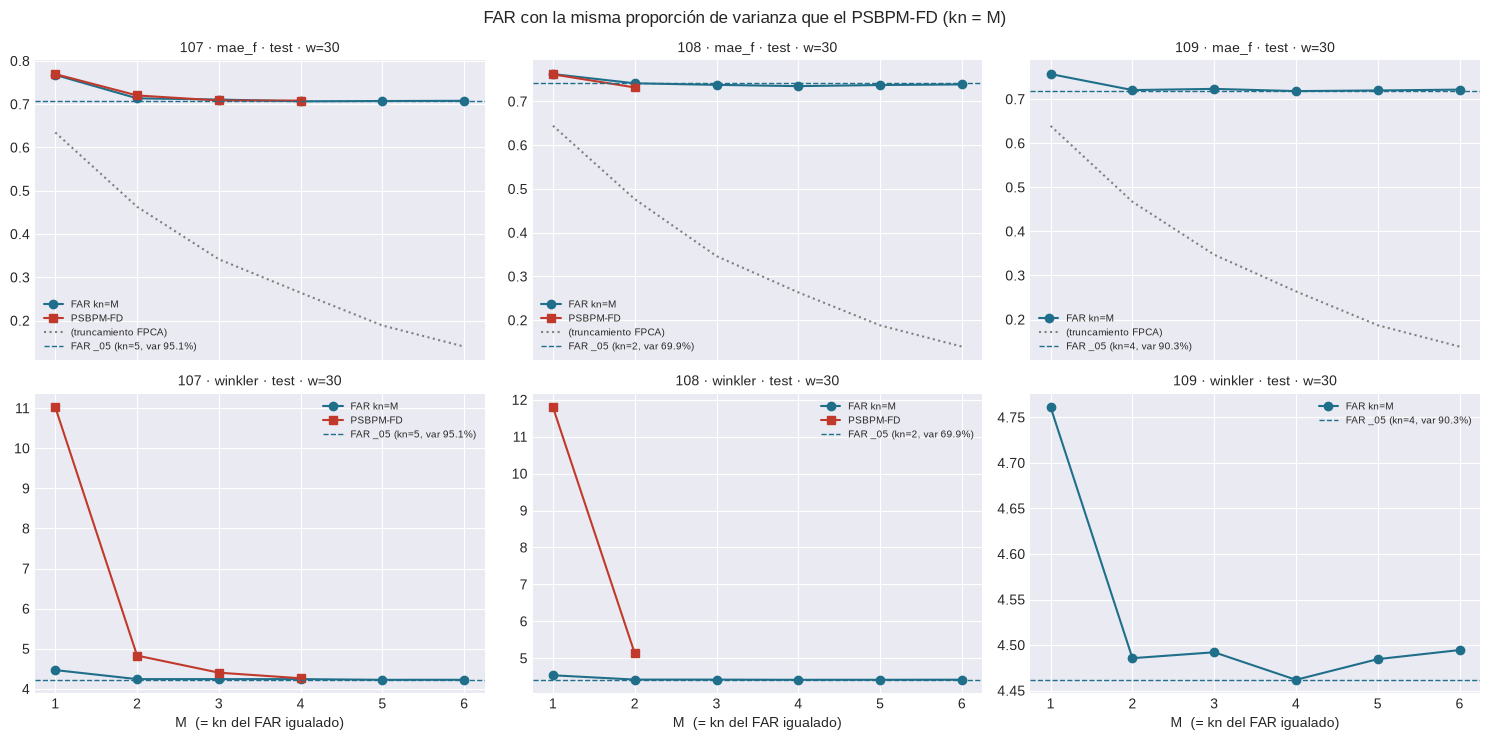

In [12]:
EST = {"FAR kn=M": dict(color="#1f6f8b", marker="o"), "PSBPM-FD": dict(color="#c0392b", marker="s"),
       "(truncamiento FPCA)": dict(color="0.5", ls=":", marker="")}
fig, ax = plt.subplots(2, 3, figsize=(15, 7.5), sharex=True)
for j, (esc, e) in enumerate(E.items()):
    r = RES[(RES.escenario == esc) & (RES.objetivo == "curva_suavizada")]
    for i, col in enumerate(("mae_f", "winkler")):
        a = ax[i, j]
        for mod, st in EST.items():
            s = r[r.modelo == mod].sort_values("M")
            if len(s) and s[col].notna().any():
                a.plot(s.M, s[col], label=mod, **st)
        s05 = r[r.modelo.str.startswith("FAR _05")]
        a.axhline(s05[col].iloc[0], color="#1f6f8b", ls="--", lw=1,
                  label=f"FAR _05 (kn={e['kn_cv']}, var {e['vac'][e['kn_cv']-1]:.1%})")
        a.set_title(f"{esc} · {col} · test · w={W_REF}", fontsize=10)
        if i == 1: a.set_xlabel("M  (= kn del FAR igualado)")
        a.legend(fontsize=7)
fig.suptitle("FAR con la misma proporción de varianza que el PSBPM-FD (kn = M)", fontsize=12)
fig.tight_layout()
for e in E.values():
    fig.savefig(e["out"] / "y05_far_kn_igualado.png", dpi=140, bbox_inches="tight")
plt.show()

## §9 Lectura

Con `R = 1` ninguna diferencia es concluyente (`CLAUDE.md §8.6`). Lo que sí es exacto:
**`kn = M` iguala la varianza**, porque los subespacios coinciden. Cualquier otro `kn` le da al FAR más
(o menos) curva que al PSBPM-FD del mismo punto.

In [13]:
for esc, e in E.items():
    r = RES[(RES.escenario == esc) & (RES.objetivo == "curva_suavizada")].set_index(["M", "modelo"])
    print(f"== {esc}: FAR del _05 con kn={e['kn_cv']} ({e['vac'][e['kn_cv']-1]:.1%} de varianza)")
    for M in M_EVAL:
        fm = r.loc[(M, "FAR kn=M")]
        linea = f"  M={M} ({e['vac'][M-1]:.1%}): FAR kn=M mae {fm.mae_f:.4f} wink {fm.winkler:.3f}"
        if (M, "PSBPM-FD") in r.index:
            ps = r.loc[(M, "PSBPM-FD")]
            linea += f"  | PSBPM mae {ps.mae_f:.4f} wink {ps.winkler:.3f}  -> dif mae {ps.mae_f - fm.mae_f:+.4f}"
        print(linea)

== 107: FAR del _05 con kn=5 (95.1% de varianza)
  M=1 (50.5%): FAR kn=M mae 0.7676 wink 4.469  | PSBPM mae 0.7696 wink 11.022  -> dif mae +0.0020
  M=2 (72.2%): FAR kn=M mae 0.7135 wink 4.243  | PSBPM mae 0.7202 wink 4.830  -> dif mae +0.0067
  M=3 (84.9%): FAR kn=M mae 0.7107 wink 4.243  | PSBPM mae 0.7086 wink 4.404  -> dif mae -0.0022
  M=4 (91.1%): FAR kn=M mae 0.7067 wink 4.243  | PSBPM mae 0.7084 wink 4.264  -> dif mae +0.0017
  M=5 (95.1%): FAR kn=M mae 0.7073 wink 4.226
  M=6 (97.3%): FAR kn=M mae 0.7078 wink 4.227
== 108: FAR del _05 con kn=2 (69.9% de varianza)
  M=1 (46.7%): FAR kn=M mae 0.7626 wink 4.537  | PSBPM mae 0.7619 wink 11.796  -> dif mae -0.0007
  M=2 (69.9%): FAR kn=M mae 0.7415 wink 4.421  | PSBPM mae 0.7320 wink 5.130  -> dif mae -0.0094
  M=3 (84.6%): FAR kn=M mae 0.7379 wink 4.420
  M=4 (91.2%): FAR kn=M mae 0.7350 wink 4.415
  M=5 (95.2%): FAR kn=M mae 0.7375 wink 4.416
  M=6 (97.3%): FAR kn=M mae 0.7389 wink 4.418
== 109: FAR del _05 con kn=4 (90.3% de var